# Experimento 4 — Combinações dos experimentos opcionais
## Objetivo
## Design ablativo

## 1. Setup

In [1]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt

SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds()
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Path("checkpoints").mkdir(exist_ok=True)
Path("figs").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

Device: cuda
GPU: NVIDIA RTX A6000


In [2]:
from src.gtsrb import (
    get_dataloaders,
    save_predictions,
    NUM_CLASSES,
    GTSRB_CLASSES,
)

MEAN = [0.3403, 0.3121, 0.3214]
STD  = [0.2724, 0.2608, 0.2669]

print(f"NUM_CLASSES = {NUM_CLASSES}")

NUM_CLASSES = 43


## 2. Funções auxiliares: augmentation parametrizada e pesos por classe

In [3]:
def make_eval_transform(img_size):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])

def make_aug_medium(img_size):
    """Pipeline aug-medium (vencedor de macro accuracy do Exp 3)."""
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomAffine(
            degrees=10,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
        ),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])

### 2.1 Pesos por classe para o weighted CrossEntropyLoss

In [ ]:
def get_train_class_counts(train_loader, num_classes):
    subset = train_loader.dataset
    if hasattr(subset, "indices") and hasattr(subset.dataset, "_samples"):
        samples = subset.dataset._samples
        labels = np.array([samples[i][1] for i in subset.indices])
        return np.bincount(labels, minlength=num_classes)
    counts = np.zeros(num_classes, dtype=int)
    for _, lbls in train_loader:
        for l in lbls.tolist():
            counts[l] += 1
    return counts

def compute_class_weights(counts, num_classes):
    total = counts.sum()
    weights = total / (num_classes * counts.clip(min=1))
    return weights

_tmp_loader, _, _ = get_dataloaders(img_size=32, batch_size=128, num_workers=0)
TRAIN_COUNTS = get_train_class_counts(_tmp_loader, NUM_CLASSES)
del _tmp_loader

class_weights_np = compute_class_weights(TRAIN_COUNTS, NUM_CLASSES)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

print("Pesos para weighted CE (top 5 mais pesadas e top 5 mais leves):")
order = np.argsort(class_weights_np)[::-1]
print("  Mais pesadas (classes raras):")
for c in order[:5]:
    print(f"    cls {c:>2d}  peso={class_weights_np[c]:.3f}  n_train={TRAIN_COUNTS[c]:>4d}  ({GTSRB_CLASSES[int(c)]})")
print("  Mais leves (classes comuns):")
for c in order[-5:]:
    print(f"    cls {c:>2d}  peso={class_weights_np[c]:.3f}  n_train={TRAIN_COUNTS[c]:>4d}  ({GTSRB_CLASSES[int(c)]})")
print(f"\nPesos das 5 classes difíceis do baseline:")
for c in [0, 30, 27, 24, 21]:
    print(f"    cls {c:>2d}  peso={class_weights_np[c]:.3f}  ({GTSRB_CLASSES[c]})")

Pesos para weighted CE (top 5 mais pesadas e top 5 mais leves):
  Mais pesadas (classes raras):
    cls 19  peso=4.165  n_train= 119  (Dangerous curve left)
    cls 37  peso=4.096  n_train= 121  (Go straight or left)
    cls  0  peso=3.997  n_train= 124  (Speed limit (20km/h))
    cls 24  peso=3.903  n_train= 127  (Road narrows right)
    cls 32  peso=3.671  n_train= 135  (End speed + passing limits)
  Mais leves (classes comuns):
    cls 38  peso=0.448  n_train=1106  (Keep right)
    cls 12  peso=0.440  n_train=1127  (Priority road)
    cls 13  peso=0.423  n_train=1171  (Yield)
    cls  1  peso=0.413  n_train=1201  (Speed limit (30km/h))
    cls  2  peso=0.412  n_train=1204  (Speed limit (50km/h))

Pesos das 5 classes difíceis do baseline:
    cls  0  peso=3.997  (Speed limit (20km/h))
    cls 30  peso=2.136  (Beware of ice/snow)
    cls 27  peso=3.395  (Pedestrians)
    cls 24  peso=3.903  (Road narrows right)
    cls 21  peso=2.636  (Double curve)


## 3. Modelo — BN-conv+fc parametrizado por img_size

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=43, img_size=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        spatial = img_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * spatial * spatial, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def build_model(img_size):
    set_all_seeds(SEED)
    return CNN(num_classes=NUM_CLASSES, img_size=img_size).to(DEVICE)

for sz in (32, 64):
    m = build_model(sz)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"img_size={sz} → params={n_params:,}")
    del m

img_size=32 → params=1,079,979
img_size=64 → params=4,225,707


## 4. Funções de treino

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    ys, ps = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        preds = model(images).argmax(1).cpu().numpy()
        ps.append(preds)
        ys.append(labels.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def per_class_accuracy(y_true, y_pred, num_classes):
    accs = np.zeros(num_classes)
    counts = np.zeros(num_classes, dtype=int)
    for c in range(num_classes):
        mask = y_true == c
        counts[c] = mask.sum()
        accs[c] = (y_pred[mask] == c).mean() if counts[c] > 0 else 0.0
    return accs, counts

## 5. Função de experimento unificada

In [ ]:
BATCH_SIZE = 128
NUM_WORKERS = 0

def make_optimizer(name, params):
    if name == "sgd_mom":
        return optim.SGD(params, lr=0.01, momentum=0.9)
    if name == "adam":
        return optim.Adam(params, lr=1e-3)
    raise ValueError(name)

def run_experiment(tag, img_size, train_transform, opt_name,
                   use_weighted_loss, num_epochs):
    print(f"\n{'=' * 78}")
    print(f"  Treinando: {tag}")
    print(f"    img_size={img_size}  opt={opt_name}  "
          f"aug={'YES' if train_transform is not None else 'no'}  "
          f"weighted_loss={'YES' if use_weighted_loss else 'no'}  "
          f"epochs={num_epochs}")
    print(f"{'=' * 78}")

    train_loader, val_loader, test_loader = get_dataloaders(
        img_size=img_size,
        batch_size=BATCH_SIZE,
        train_transform=train_transform,
        num_workers=NUM_WORKERS,
    )

    model = build_model(img_size)
    if use_weighted_loss:
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(opt_name, model.parameters())

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_epoch = 0.0, 0
    ckpt_path = f"checkpoints/exp4_{tag}_best.pt"

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        flag = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), ckpt_path)
            flag = "  <-- melhor val_acc"

        print(f"  Epoch {epoch:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f}{flag}")
    elapsed = time.time() - t0
    print(f"\n  Tempo: {elapsed:.1f}s  ({elapsed/60:.1f} min)  | "
          f"Melhor val_acc: {best_val_acc:.4f} (ep {best_epoch})")

    return {
        "tag": tag,
        "img_size": img_size,
        "opt_name": opt_name,
        "use_weighted_loss": use_weighted_loss,
        "use_aug": train_transform is not None,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "elapsed_sec": elapsed,
        "ckpt_path": ckpt_path,
        "test_loader": test_loader,
    }

## 6. Rodadas (5 experimentos)

In [ ]:
CONFIGS = [
    ("img64",         64, None,             "sgd_mom", False, 20),
    ("weighted",      32, None,             "sgd_mom", True,  20),
    ("adam_aug",      32, make_aug_medium,  "adam",    False, 30),
    ("img64_aug",     64, make_aug_medium,  "sgd_mom", False, 30),
    ("kitchen_sink",  64, make_aug_medium,  "sgd_mom", True,  30),
]

all_results = {}
for tag, img_size, aug_fn, opt_name, weighted, n_ep in CONFIGS:
    train_transform = aug_fn(img_size) if aug_fn is not None else None
    all_results[tag] = run_experiment(
        tag=tag,
        img_size=img_size,
        train_transform=train_transform,
        opt_name=opt_name,
        use_weighted_loss=weighted,
        num_epochs=n_ep,
    )


  Treinando: img64
    img_size=64  opt=sgd_mom  aug=no  weighted_loss=no  epochs=20
  Epoch 01/20 | train_loss=0.9166 acc=0.8043 | val_loss=0.2192 acc=0.9673  <-- melhor val_acc
  Epoch 02/20 | train_loss=0.1104 acc=0.9870 | val_loss=0.1111 acc=0.9803  <-- melhor val_acc
  Epoch 03/20 | train_loss=0.0412 acc=0.9971 | val_loss=0.0634 acc=0.9906  <-- melhor val_acc
  Epoch 04/20 | train_loss=0.0198 acc=0.9991 | val_loss=0.0445 acc=0.9942  <-- melhor val_acc
  Epoch 05/20 | train_loss=0.0118 acc=0.9999 | val_loss=0.0344 acc=0.9942
  Epoch 06/20 | train_loss=0.0082 acc=1.0000 | val_loss=0.0320 acc=0.9944  <-- melhor val_acc
  Epoch 07/20 | train_loss=0.0064 acc=1.0000 | val_loss=0.0322 acc=0.9936
  Epoch 08/20 | train_loss=0.0051 acc=1.0000 | val_loss=0.0284 acc=0.9949  <-- melhor val_acc
  Epoch 09/20 | train_loss=0.0042 acc=1.0000 | val_loss=0.0268 acc=0.9947
  Epoch 10/20 | train_loss=0.0036 acc=1.0000 | val_loss=0.0285 acc=0.9946
  Epoch 11/20 | train_loss=0.0033 acc=1.0000 | val_los

In [ ]:
summary = {}
for tag, r in all_results.items():
    summary[tag] = {k: v for k, v in r.items() if k not in ("ckpt_path", "test_loader")}
with open("checkpoints/exp4_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp4_summary.json")

Resumo salvo em checkpoints/exp4_summary.json


## 7. Avaliação no conjunto de teste

In [ ]:
test_results = {}

for tag, r in all_results.items():
    model = CNN(num_classes=NUM_CLASSES, img_size=r["img_size"]).to(DEVICE)
    model.load_state_dict(torch.load(r["ckpt_path"], map_location=DEVICE))
    y_true, y_pred = predict_all(model, r["test_loader"], DEVICE)
    assert y_pred.shape == (12630,)

    per_class_acc, _ = per_class_accuracy(y_true, y_pred, NUM_CLASSES)
    test_results[tag] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "per_class_acc": per_class_acc,
        "global_acc": float((y_pred == y_true).mean()),
        "macro_acc": float(per_class_acc.mean()),
    }
    print(f"  {tag:<15s} | global={test_results[tag]['global_acc']:.4f} | "
          f"macro={test_results[tag]['macro_acc']:.4f}")

  img64           | global=0.9305 | macro=0.8972
  weighted        | global=0.9335 | macro=0.9013
  adam_aug        | global=0.9224 | macro=0.8942
  img64_aug       | global=0.9138 | macro=0.8759
  kitchen_sink    | global=0.8788 | macro=0.8580


## 8. Tabela mestre (com referências dos Exp 2 e Exp 3)

In [ ]:
REFERENCES = {
    "ref_exp2 (BN+SGDmom, img32, no aug, 20ep)": {
        "val": 0.9974, "test_global": 0.9363, "test_macro": 0.8993,
        "hard5_mean": 0.6213,
        "tag_for_csv": "(ver predicoes_exp2_BN_conv_fc__sgd_mom.csv)",
    },
    "ref_exp3 (BN+SGDmom, img32, aug-med, 30ep)": {
        "val": 0.9992, "test_global": 0.9292, "test_macro": 0.8988,
        "hard5_mean": 0.6998,
        "tag_for_csv": "(ver predicoes_exp3_aug_medium.csv)",
    },
}

print(f"  {'Configuração':<55s} | {'val':>7s} | {'test glob':>9s} | {'test macro':>10s} | {'gap v→t':>8s}")
print("-" * 110)
for name, m in REFERENCES.items():
    gap = m["test_global"] - m["val"]
    print(f"  {name:<55s} | {m['val']:>7.4f} | {m['test_global']:>9.4f} | "
          f"{m['test_macro']:>10.4f} | {gap:>+8.4f}")

print("-" * 110)
for tag, r in all_results.items():
    tr = test_results[tag]
    gap = tr["global_acc"] - r["best_val_acc"]
    desc = f"exp4 {tag}  (img={r['img_size']}, {r['opt_name']}, "
    desc += f"{'aug' if r['use_aug'] else 'no aug'}, "
    desc += f"{'weighted' if r['use_weighted_loss'] else 'CE std'})"
    print(f"  {desc:<55s} | {r['best_val_acc']:>7.4f} | {tr['global_acc']:>9.4f} | "
          f"{tr['macro_acc']:>10.4f} | {gap:>+8.4f}")

  Configuração                                            |     val | test glob | test macro |  gap v→t
--------------------------------------------------------------------------------------------------------------
  ref_exp2 (BN+SGDmom, img32, no aug, 20ep)               |  0.9974 |    0.9363 |     0.8993 |  -0.0611
  ref_exp3 (BN+SGDmom, img32, aug-med, 30ep)              |  0.9992 |    0.9292 |     0.8988 |  -0.0700
--------------------------------------------------------------------------------------------------------------
  exp4 img64  (img=64, sgd_mom, no aug, CE std)           |  0.9957 |    0.9305 |     0.8972 |  -0.0652
  exp4 weighted  (img=32, sgd_mom, no aug, weighted)      |  0.9972 |    0.9335 |     0.9013 |  -0.0637
  exp4 adam_aug  (img=32, adam, aug, CE std)              |  0.9985 |    0.9224 |     0.8942 |  -0.0761
  exp4 img64_aug  (img=64, sgd_mom, aug, CE std)          |  0.9991 |    0.9138 |     0.8759 |  -0.0853
  exp4 kitchen_sink  (img=64, sgd_mom, aug, weight

### 8.1 Ablação isolada

In [12]:
ref_global = REFERENCES["ref_exp2 (BN+SGDmom, img32, no aug, 20ep)"]["test_global"]
ref_macro  = REFERENCES["ref_exp2 (BN+SGDmom, img32, no aug, 20ep)"]["test_macro"]
ref3_global = REFERENCES["ref_exp3 (BN+SGDmom, img32, aug-med, 30ep)"]["test_global"]
ref3_macro  = REFERENCES["ref_exp3 (BN+SGDmom, img32, aug-med, 30ep)"]["test_macro"]

def fmt_delta(d):
    return f"{d:+.4f}"

print("Efeito isolado de cada técnica (vs Exp 2 BN+SGDmom+img32+no aug):")
for tag in ("img64", "weighted"):
    tr = test_results[tag]
    print(f"  +{tag:<14s} → Δ global = {fmt_delta(tr['global_acc']-ref_global)} | "
          f"Δ macro = {fmt_delta(tr['macro_acc']-ref_macro)}")

print()
print("Combinações:")
print(f"  img64 + aug-medium       vs img64 alone        → "
      f"Δ global = {fmt_delta(test_results['img64_aug']['global_acc']-test_results['img64']['global_acc'])} | "
      f"Δ macro = {fmt_delta(test_results['img64_aug']['macro_acc']-test_results['img64']['macro_acc'])}")
print(f"  img64+aug+weighted (sink) vs img64+aug         → "
      f"Δ global = {fmt_delta(test_results['kitchen_sink']['global_acc']-test_results['img64_aug']['global_acc'])} | "
      f"Δ macro = {fmt_delta(test_results['kitchen_sink']['macro_acc']-test_results['img64_aug']['macro_acc'])}")
print(f"  Adam + aug-medium        vs SGDmom + aug-medium (Exp 3) → "
      f"Δ global = {fmt_delta(test_results['adam_aug']['global_acc']-ref3_global)} | "
      f"Δ macro = {fmt_delta(test_results['adam_aug']['macro_acc']-ref3_macro)}")

Efeito isolado de cada técnica (vs Exp 2 BN+SGDmom+img32+no aug):
  +img64          → Δ global = -0.0058 | Δ macro = -0.0021
  +weighted       → Δ global = -0.0028 | Δ macro = +0.0020

Combinações:
  img64 + aug-medium       vs img64 alone        → Δ global = -0.0167 | Δ macro = -0.0212
  img64+aug+weighted (sink) vs img64+aug         → Δ global = -0.0350 | Δ macro = -0.0179
  Adam + aug-medium        vs SGDmom + aug-medium (Exp 3) → Δ global = -0.0068 | Δ macro = -0.0046


## 9. As 5 classes difíceis do baseline

In [13]:
HARD_CLASSES = [0, 30, 27, 24, 21]

print(f"  {'Classe':<8s} | " + " | ".join(f"{tag:>15s}" for tag in all_results))
print("-" * (8 + 18 * len(all_results)))
for c in HARD_CLASSES:
    row_vals = [test_results[tag]["per_class_acc"][c] for tag in all_results]
    row = f"  cls {c:>2d}  | " + " | ".join(f"{v:>15.4f}" for v in row_vals)
    print(row + f"  ({GTSRB_CLASSES[c]})")

print()
print("  Média sobre as 5 classes difíceis (incluindo referências):")
print(f"    ref_exp2 (BN+SGDmom, no aug)         = 0.6213")
print(f"    ref_exp3 (BN+SGDmom, aug-medium)     = 0.6998")
for tag in all_results:
    m = float(np.mean([test_results[tag]["per_class_acc"][c] for c in HARD_CLASSES]))
    print(f"    {tag:<35s}  = {m:.4f}")

  Classe   |           img64 |        weighted |        adam_aug |       img64_aug |    kitchen_sink
--------------------------------------------------------------------------------------------------
  cls  0  |          0.4167 |          0.6000 |          0.8500 |          0.3667 |          0.3333  (Speed limit (20km/h))
  cls 30  |          0.6133 |          0.5133 |          0.4200 |          0.5067 |          0.4333  (Beware of ice/snow)
  cls 27  |          0.9500 |          0.5167 |          0.6833 |          0.8333 |          0.9167  (Pedestrians)
  cls 24  |          0.6889 |          0.7556 |          0.9444 |          0.9222 |          0.9667  (Road narrows right)
  cls 21  |          0.8111 |          0.8333 |          0.7444 |          0.8111 |          0.8444  (Double curve)

  Média sobre as 5 classes difíceis (incluindo referências):
    ref_exp2 (BN+SGDmom, no aug)         = 0.6213
    ref_exp3 (BN+SGDmom, aug-medium)     = 0.6998
    img64                              

### 9.1 Especialização: o weighted CE salvou a classe 0 e a 30?

In [ ]:
TARGETS = [0, 30] 

print(f"  {'Classe':<8s} | {'ref_exp2':>10s} | {'weighted':>10s} | {'kitchen_sink':>13s} | n_treino")
print("-" * 70)

ref_exp2_per_class = {0: 0.5167, 30: 0.5400, 27: 0.5167, 24: 0.7111, 21: 0.8222}
for c in TARGETS:
    ref_v = ref_exp2_per_class.get(c, float("nan"))
    print(f"  cls {c:>2d}  | {ref_v:>10.4f} | "
          f"{test_results['weighted']['per_class_acc'][c]:>10.4f} | "
          f"{test_results['kitchen_sink']['per_class_acc'][c]:>13.4f} | "
          f"{TRAIN_COUNTS[c]:>4d}  ({GTSRB_CLASSES[c]})")

  Classe   |   ref_exp2 |   weighted |  kitchen_sink | n_treino
----------------------------------------------------------------------
  cls  0  |     0.5167 |     0.6000 |        0.3333 |  124  (Speed limit (20km/h))
  cls 30  |     0.5400 |     0.5133 |        0.4333 |  232  (Beware of ice/snow)


## 10. Acurácia por classe

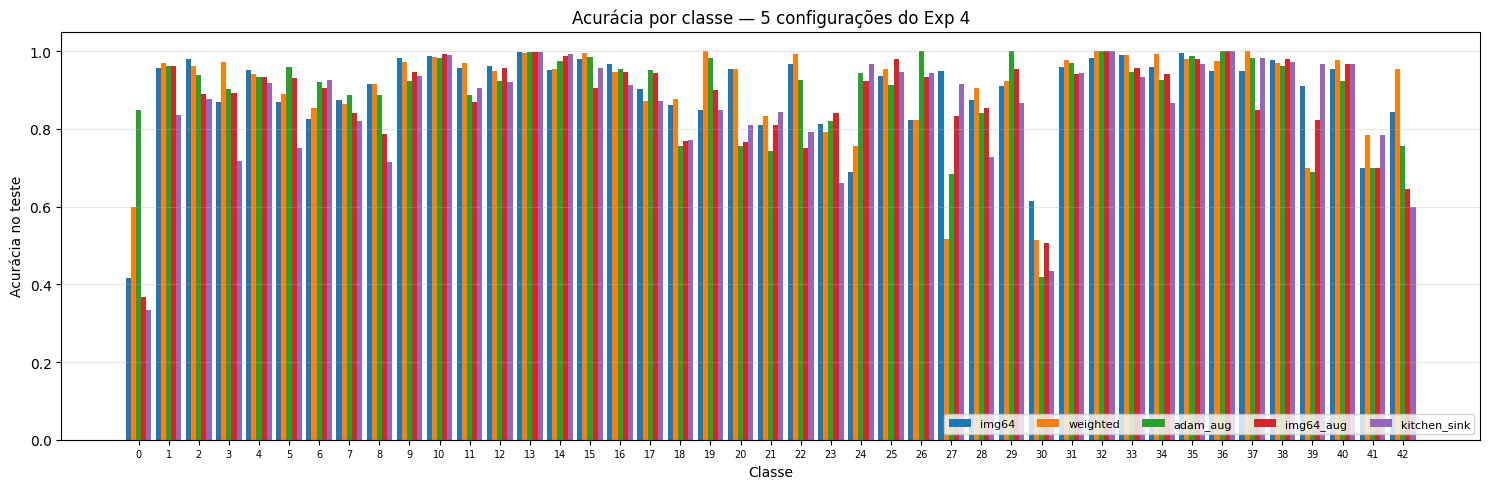

In [15]:
COLORS = {
    "img64":         "tab:blue",
    "weighted":      "tab:orange",
    "adam_aug":      "tab:green",
    "img64_aug":     "tab:red",
    "kitchen_sink":  "tab:purple",
}

fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(NUM_CLASSES)
width = 0.17
tags = list(all_results.keys())
for i, tag in enumerate(tags):
    ax.bar(x + (i - 2) * width, test_results[tag]["per_class_acc"], width,
           label=tag, color=COLORS[tag])
ax.set_xlabel("Classe"); ax.set_ylabel("Acurácia no teste")
ax.set_title("Acurácia por classe — 5 configurações do Exp 4")
ax.set_xticks(x); ax.set_xticklabels(x, fontsize=7)
ax.set_ylim(0, 1.05); ax.legend(loc="lower right", ncol=5, fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figs/exp4_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Salvar predições

In [16]:
for tag, tr in test_results.items():
    out_path = f"results/predicoes_exp4_{tag}.csv"
    r = all_results[tag]
    desc = f"Exp4 {tag} | img={r['img_size']} | {r['opt_name']} | "
    desc += f"{'aug-medium' if r['use_aug'] else 'no aug'} | "
    desc += f"{'weighted CE' if r['use_weighted_loss'] else 'std CE'}"
    save_predictions(tr["y_pred"], out_path, experiment_name=desc)
    print(f"  {out_path}")

  results/predicoes_exp4_img64.csv
  results/predicoes_exp4_weighted.csv
  results/predicoes_exp4_adam_aug.csv
  results/predicoes_exp4_img64_aug.csv
  results/predicoes_exp4_kitchen_sink.csv


## 12. Eleição do modelo final

In [ ]:
candidates = []

candidates.append({
    "name": "ref_exp2 BN+SGDmom img32 no aug 20ep",
    "global": REFERENCES["ref_exp2 (BN+SGDmom, img32, no aug, 20ep)"]["test_global"],
    "macro":  REFERENCES["ref_exp2 (BN+SGDmom, img32, no aug, 20ep)"]["test_macro"],
    "source_csv": "results/predicoes_exp2_BN_conv_fc__sgd_mom.csv",
    "y_pred": None,
})
candidates.append({
    "name": "ref_exp3 BN+SGDmom img32 aug-medium 30ep",
    "global": REFERENCES["ref_exp3 (BN+SGDmom, img32, aug-med, 30ep)"]["test_global"],
    "macro":  REFERENCES["ref_exp3 (BN+SGDmom, img32, aug-med, 30ep)"]["test_macro"],
    "source_csv": "results/predicoes_exp3_aug_medium.csv",
    "y_pred": None,
})

for tag, tr in test_results.items():
    candidates.append({
        "name": f"exp4_{tag}",
        "global": tr["global_acc"],
        "macro": tr["macro_acc"],
        "source_csv": f"results/predicoes_exp4_{tag}.csv",
        "y_pred": tr["y_pred"],
    })

best_global = max(candidates, key=lambda d: d["global"])
best_macro  = max(candidates, key=lambda d: d["macro"])

print("Top 5 por test GLOBAL:")
for d in sorted(candidates, key=lambda d: -d["global"])[:5]:
    print(f"  global={d['global']:.4f}  macro={d['macro']:.4f}  ← {d['name']}")

print("\nTop 5 por test MACRO:")
for d in sorted(candidates, key=lambda d: -d["macro"])[:5]:
    print(f"  macro={d['macro']:.4f}  global={d['global']:.4f}  ← {d['name']}")

print(f"\nMelhor por GLOBAL: {best_global['name']}")
print(f"  → CSV: {best_global['source_csv']}")
print(f"Melhor por MACRO:  {best_macro['name']}")
print(f"  → CSV: {best_macro['source_csv']}")

Top 5 por test GLOBAL:
  global=0.9363  macro=0.8993  ← ref_exp2 BN+SGDmom img32 no aug 20ep
  global=0.9335  macro=0.9013  ← exp4_weighted
  global=0.9305  macro=0.8972  ← exp4_img64
  global=0.9292  macro=0.8988  ← ref_exp3 BN+SGDmom img32 aug-medium 30ep
  global=0.9224  macro=0.8942  ← exp4_adam_aug

Top 5 por test MACRO:
  macro=0.9013  global=0.9335  ← exp4_weighted
  macro=0.8993  global=0.9363  ← ref_exp2 BN+SGDmom img32 no aug 20ep
  macro=0.8988  global=0.9292  ← ref_exp3 BN+SGDmom img32 aug-medium 30ep
  macro=0.8972  global=0.9305  ← exp4_img64
  macro=0.8942  global=0.9224  ← exp4_adam_aug

Melhor por GLOBAL: ref_exp2 BN+SGDmom img32 no aug 20ep
  → CSV: results/predicoes_exp2_BN_conv_fc__sgd_mom.csv
Melhor por MACRO:  exp4_weighted
  → CSV: results/predicoes_exp4_weighted.csv
